<a href="https://colab.research.google.com/github/Shivam-Singh-IN18/Projects_/blob/main/AI%20Enhanced%20Arythmia%20Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ===============================================================
# ✅ Cell 1 (Final – Full Import + Robust Multi-Lead Loader)
# ===============================================================

import os, time, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import butter, filtfilt, iirnotch, find_peaks
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.utils import resample

try:
    from imblearn.over_sampling import SMOTE
    smote_available = True
except Exception:
    smote_available = False

warnings.filterwarnings("ignore")
sns.set()

# ---------------------------------------------------------------
# 🗂️ Project directories (Fixed for Windows)
# ---------------------------------------------------------------
BASE_DIR = Path(r"/content/drive/MyDrive/Major_Project_ETC29/7th SEM/Final_Arrythmia_Detection_Model_7thNov")
DATA_DIR = BASE_DIR / "Dataset"
ANN_DIR = BASE_DIR / "Annotations"
PKL_DIR = BASE_DIR / "PKL_FILE"
RESULTS_DIR = BASE_DIR / "Results"
for d in [PKL_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------
# ⚙️ Constants
# ---------------------------------------------------------------
FS = 360
WINDOW = int(0.15 * FS)   # ±150 ms

# === Correct label + combine maps (official) ===
LABEL_MAP = {
    'N': 0, 'L': 1, 'R': 2, 'A': 3, 'V': 4, 'E': 5, 'F': 6,
    '+': 7, '/': 8, 'Q': 9, 'VT': 10,
    'NOISE': -1, '(NOISE': -1, '(NOISE)': -1, 'ARTIFACT': -1
}

COMBINE_MAP = {
    0: 0, 1: 0, 2: 0,     # N, L, R → Normal
    3: 1,                 # A → AFib
    4: 2, 5: 2, 10: 2,    # V, E, VT → Ventricular
    6: 0, 7: 0, 8: 0, 9: 0  # F, +, /, Q → Normal-like
}

# ---------------------------------------------------------------
# 🧠 Smart ECG loader: works with 1–2 leads + symbol column
# ---------------------------------------------------------------
def load_ecg_csv(filepath: Path):
    """
    Load an ECG CSV safely with variable leads and symbol column.
    Returns (signal_array, symbol_array). Handles all leads & fixes length mismatch.
    """
    try:
        df = pd.read_csv(filepath, dtype=str, on_bad_lines="skip").replace(
            ["", " ", "nan", "NaN"], np.nan
        )
        df = df.dropna(how="all").reset_index(drop=True)

        # Identify ECG leads
        ecg_cols = [
            c for c in df.columns
            if any(x in c.lower() for x in ["ml", "v", "ecg", "lead", "ii", "i", "iii"])
            and "symbol" not in c.lower()
            and "annot" not in c.lower()
        ]
        if not ecg_cols:
            raise ValueError("No ECG lead columns found")

        # Identify possible symbol column
        sym_col = next(
            (c for c in df.columns if "sym" in c.lower() or "annot" in c.lower()), None
        )

        # Convert leads to numeric and fix NaNs
        for c in ecg_cols:
            df[c] = pd.to_numeric(df[c], errors="coerce")
        df = df.fillna(method="ffill").fillna(method="bfill")

        # Equalize length across all leads
        min_len = min(len(df[c].dropna()) for c in ecg_cols)
        for c in ecg_cols:
            df[c] = df[c].iloc[:min_len]
        df = df.reset_index(drop=True)

        # Combine 1 or 2 leads (mean if 2)
        if len(ecg_cols) > 2:
            ecg_cols = ecg_cols[:2]
        sig = (
            df[ecg_cols].mean(axis=1).values
            if len(ecg_cols) > 1
            else df[ecg_cols[0]].values
        )
        sig = np.nan_to_num(sig.astype(float))

        # Symbols
        if sym_col and sym_col in df.columns:
            symbols = df[sym_col].fillna("").astype(str).values[: len(sig)]
        else:
            symbols = np.array([""] * len(sig))

        print(
            f"✅ {filepath.name}: leads={len(ecg_cols)} ({', '.join(ecg_cols)}) "
            f"| symbols={'yes' if sym_col else 'no'} | samples={len(sig)}"
        )
        return sig, symbols

    except Exception as e:
        print(f"⚠️ Skipped {filepath.name}: {e}")
        return np.array([]), np.array([])

# ---------------------------------------------------------------
# ✅ Sanity test
# ---------------------------------------------------------------
sample_files = sorted(DATA_DIR.glob("*_ekg.csv"))
if sample_files:
    sig, sym = load_ecg_csv(sample_files[0])
    print(f"Test signal shape: {sig.shape}, symbols: {len(sym)}")
else:
    print("⚠️ No ECG files found in DATA_DIR.")

print("FS =", FS, "| WINDOW =", WINDOW, "| SMOTE available:", smote_available)


✅ 100_ekg.csv: leads=2 (MLII, V5) | symbols=yes | samples=650000
Test signal shape: (650000,), symbols: 650000
FS = 360 | WINDOW = 54 | SMOTE available: True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Cell 2
_filter_cache = {}

def _design_filters(fs):
    if fs in _filter_cache:
        return _filter_cache[fs]
    b_hp, a_hp = butter(2, 0.5/(fs/2), btype='high')
    b_lp, a_lp = butter(2, 45/(fs/2), btype='low')
    _filter_cache[fs] = (b_hp, a_hp, b_lp, a_lp)
    return _filter_cache[fs]

def bandpass_notch_filter(sig, fs=FS):
    b_hp, a_hp, b_lp, a_lp = _design_filters(fs)
    sig = filtfilt(b_hp, a_hp, sig)
    b_i, a_i = iirnotch(50/(fs/2), 30)
    sig = filtfilt(b_i, a_i, sig)
    sig = filtfilt(b_lp, a_lp, sig)
    return sig

def safe_to_array(x):
    if isinstance(x, (list, np.ndarray)):
        return np.array(x, dtype=float)
    if isinstance(x, str):
        s = x.replace('[',' ').replace(']',' ')
        try:
            return np.array([float(v) for v in s.split()], dtype=float)
        except:
            return np.array([], dtype=float)
    return np.array([], dtype=float)


In [ ]:
# Cell 3: Pan-Tompkins (faithful to your MATLAB logic)
def pan_tompkins_detect(signal, fs=FS):
    # replicate your MATLAB steps: filter -> derivative -> squared -> movmean -> adaptive thresholds
    # Filtering: HP -> notch -> LP (we already have bandpass_notch_filter but for detection use this chain)
    # Use same coefficients as earlier conversion
    # HP
    b_hp, a_hp = butter(2, 0.5 / (fs/2), btype='high')
    hp_filtered = filtfilt(b_hp, a_hp, signal)

    # notch (IIR notch approx)
    notch_freq = 50.0
    Q = 30.0
    b_notch, a_notch = iirnotch(notch_freq/(fs/2), notch_freq/(fs*Q))
    notch_filtered = filtfilt(b_notch, a_notch, hp_filtered)

    # LP
    b_lp, a_lp = butter(2, 45/(fs/2), btype='low')
    filtered_signal = filtfilt(b_lp, a_lp, notch_filtered)

    # derivative, squared, integrated
    derivative_signal = np.diff(filtered_signal, prepend=filtered_signal[0])
    squared_signal = derivative_signal ** 2
    window_size = max(1, int(round(0.075 * fs)))
    integrated_signal = np.convolve(squared_signal, np.ones(window_size)/window_size, mode='same')

    # Initialization (like your MATLAB)
    init_win = min(int(1 * fs), len(integrated_signal))
    SPKI = np.max(integrated_signal[:init_win]) * 0.8
    NPKI = np.median(integrated_signal[:init_win]) * 0.6
    TH1 = NPKI + 0.25 * (SPKI - NPKI)
    TH2 = 0.5 * TH1
    decay_factor = 0.995

    refractory_period = int(0.25 * fs)
    qrsPeaks = []
    missedPeaks = []
    RR_intervals = []
    last_detection = -np.inf
    searchback_used = False

    # candidate peaks based on integrated and filtered domains
    locs_I, _ = find_peaks(integrated_signal, distance=refractory_period)
    locs_F, _ = find_peaks(filtered_signal, distance=refractory_period)
    tol = int(round(0.05*fs))

    candidate_locs = []
    for li in locs_I:
        diffs = np.abs(locs_F - li)
        if np.any(diffs <= tol):
            candidate_locs.append(li)
    candidate_locs = np.unique(np.sort(candidate_locs))

    for loc in candidate_locs:
        if loc >= len(integrated_signal) or loc >= len(filtered_signal):
            continue

        w_start = max(0, loc - tol)
        w_end = min(len(filtered_signal)-1, loc + tol)
        max_idx = np.argmax(filtered_signal[w_start:w_end+1])
        loc_ref = w_start + max_idx

        peak_I = integrated_signal[loc_ref]
        peak_F = filtered_signal[loc_ref]

        # T-wave rejection
        if len(RR_intervals) >= 8:
            avg_RR = np.mean(RR_intervals)
            twave_window = int(round(max(0.36*fs, 0.4*avg_RR)))
        else:
            twave_window = int(round(0.36*fs))
        if len(qrsPeaks) > 0 and ((loc_ref - qrsPeaks[-1]) < twave_window):
            continue

        # refractory
        if len(qrsPeaks) > 0 and ((loc_ref - qrsPeaks[-1]) < refractory_period):
            continue

        # amplitude check
        if len(qrsPeaks) >= 8:
            recent_idx = qrsPeaks[-7:] if len(qrsPeaks) >= 7 else qrsPeaks
            recent_amp = np.median(filtered_signal[recent_idx])
            if peak_F < 0.6 * recent_amp:
                continue

        # dual-domain scoring
        if (peak_I > TH1) and (peak_F > (0.5 * np.max(filtered_signal))):
            SPKI = 0.125 * peak_I + 0.875 * SPKI
            qrsPeaks.append(loc_ref)
            if len(qrsPeaks) > 1:
                RR_intervals.append(qrsPeaks[-1] - qrsPeaks[-2])
            last_detection = loc_ref
            searchback_used = False
        elif peak_I > TH2:
            missedPeaks.append((loc_ref, peak_I))
            NPKI = 0.125 * peak_I + 0.875 * NPKI
        else:
            NPKI = 0.125 * peak_I + 0.875 * NPKI

        TH1 = NPKI + 0.25 * (SPKI - NPKI)
        TH2 = 0.5 * TH1

        # searchback
        if len(RR_intervals) >= 8 and len(qrsPeaks) > 0 and not searchback_used:
            avg_RR = np.mean(RR_intervals)
            if (loc_ref - qrsPeaks[-1]) > 1.66 * avg_RR and len(missedPeaks) > 0:
                cand_idx = [m for m in missedPeaks if m[0] > qrsPeaks[-1]]
                if len(cand_idx) > 0:
                    missed_loc, _ = max(cand_idx, key=lambda x: x[1])
                    recent_mean = np.mean(filtered_signal[qrsPeaks[-3]:]) if len(qrsPeaks) >= 3 else np.mean(filtered_signal[qrsPeaks])
                    if peak_F > 0.6 * recent_mean:
                        qrsPeaks.append(missed_loc)
                        RR_intervals.append(qrsPeaks[-1] - qrsPeaks[-2])
                        searchback_used = True
                    missedPeaks = []

        if (loc_ref - last_detection) > fs:
            TH1 = TH1 * decay_factor
            TH2 = 0.5 * TH1

    # refine peaks
    refined = []
    radius = int(round(0.05*fs))
    for p in qrsPeaks:
        s = max(0, p-radius)
        e = min(len(filtered_signal)-1, p+radius)
        ridx = s + np.argmax(filtered_signal[s:e+1])
        refined.append(ridx)
    refined = np.unique(refined)
    return np.array(refined, dtype=int)


In [ ]:
# Cell 4
signals_list, labels_list = [], []

def clean_symbol(sym):
    return str(sym).replace("(", "").replace(")", "").strip()

for file_name in sorted(os.listdir(DATA_DIR)):
    if not file_name.endswith(".csv"):
        continue

    base = os.path.splitext(file_name)[0]
    ann_base = base.replace("_ekg", "") if base.endswith("_ekg") else base

    df_ecg = pd.read_csv(DATA_DIR / file_name)
    if 'ecg' in df_ecg.columns:
        signal = df_ecg['ecg'].values
    elif {'V5','V2'}.issubset(df_ecg.columns):
        signal = np.mean(df_ecg[['V5','V2']].values, axis=1)
    else:
        signal = df_ecg.iloc[:,1].values

    ann_files = [f for f in os.listdir(ANN_DIR) if f.startswith(ann_base) and "_annotations_1" in f]
    if not ann_files:
        ann_files = [f for f in os.listdir(ANN_DIR) if f.startswith(ann_base)]

    combined_ann = pd.DataFrame()
    for af in sorted(ann_files):
        df_ann = pd.read_csv(ANN_DIR / af)
        idx_col, sym_col = df_ann.columns[0], df_ann.columns[1]
        df_ann[sym_col] = df_ann[sym_col].apply(clean_symbol)
        combined_ann = pd.concat([combined_ann, df_ann[[idx_col, sym_col]]])

    combined_ann = combined_ann.sort_values(by=idx_col).reset_index(drop=True)

    for i, sym in zip(combined_ann[idx_col], combined_ann[sym_col]):
        if sym not in LABEL_MAP or LABEL_MAP[sym] == -1:
            continue
        i = int(i)
        if i-WINDOW < 0 or i+WINDOW >= len(signal):
            continue
        beat = signal[i-WINDOW:i+WINDOW]
        signals_list.append(beat)
        labels_list.append(LABEL_MAP[sym])

signals = np.array(signals_list, dtype=object)
labels = np.array(labels_list, dtype=int)

print("Extracted beats:", len(signals), "Unique labels:", np.unique(labels))


Extracted beats: 109280 Unique labels: [0 1 2 3 4 5 6 7 8 9]


In [ ]:
# ===============================================================
# Cell 5: Convert to 4-class labels + Feature Extraction + Balance
# ===============================================================

def extract_features(beat):
    beat = safe_to_array(beat)
    if len(beat) < 10:
        return None

    # Normalize per beat
    beat = (beat - np.mean(beat)) / (np.std(beat) + 1e-8)

    # Basic morphological features
    p2p = np.max(beat) - np.min(beat)
    energy = np.sum(beat**2)
    slope = np.mean(np.diff(beat))
    kurt = pd.Series(beat).kurtosis()
    skew = pd.Series(beat).skew()

    # R-peak amplitude relative center
    r_amp = beat[len(beat)//2]

    # QRS width approx (threshold half peak)
    half = r_amp * 0.5
    above = np.where(beat > half)[0]
    qrsw = (above[-1] - above[0]) if len(above) > 1 else 0

    # RR placeholder (will fill later using rolling)
    rr = np.nan

    return [p2p, energy, slope, kurt, skew, r_amp, qrsw, rr]

# 1) Convert original label → arrhythmia group (4-class first)
labels_4 = np.array([COMBINE_MAP.get(l, np.nan) for l in labels], dtype=float)

# Drop NaN/unusable mappings
signals_clean = []
labels_clean = []

for b, l in zip(signals, labels_4):
    if np.isnan(l):
        continue
    signals_clean.append(b)
    labels_clean.append(int(l))

signals_clean = np.array(signals_clean, dtype=object)
labels_clean = np.array(labels_clean, dtype=int)

# 2) Extract features
feat_list = []
for beat in signals_clean:
    f = extract_features(beat)
    if f is None: continue
    feat_list.append(f)

df_feat = pd.DataFrame(feat_list, columns=[
    "p2p", "energy", "slope", "kurt", "skew", "r_amp", "qrsw", "rr"
])
df_feat["label"] = labels_clean[:len(df_feat)]

# 3) Compute RR intervals (beat-to-beat timing surrogate)
for cls in df_feat["label"].unique():
    idx = df_feat[df_feat["label"] == cls].index
    rr_vals = np.diff(idx, prepend=idx[0]) / FS
    df_feat.loc[idx, "rr"] = rr_vals

# 4) Class balancing
X = df_feat.drop(columns=["label"]).values
y = df_feat["label"].values

if smote_available:
    print("Using SMOTE balancing...")
    sm = SMOTE(random_state=42)
    X_res, y_res = sm.fit_resample(X, y)
else:
    print("SMOTE not available → Using manual upsampling...")
    df_major = df_feat[df_feat.label == df_feat.label.value_counts().idxmax()]
    df_bal = df_major.copy()
    for cls in df_feat.label.unique():
        df_cls = df_feat[df_feat.label == cls]
        df_bal = pd.concat([df_bal, resample(df_cls, replace=True, n_samples=len(df_major))])
    df_bal = df_bal.sample(frac=1).reset_index(drop=True)
    X_res = df_bal.drop(columns=["label"]).values
    y_res = df_bal["label"].values

df_bal = pd.DataFrame(X_res, columns=df_feat.columns[:-1])
df_bal["label"] = y_res.astype(int)

print("Balanced dataset shape:", df_bal.shape)
print(df_bal.label.value_counts())


Using SMOTE balancing...
Balanced dataset shape: (298497, 9)
label
0    99499
1    99499
2    99499
Name: count, dtype: int64


In [ ]:
# ===============================================================
# ✅ Cell 6: Hybrid Feature Extraction (Filtered Morphology + RR Context)
# ===============================================================

# 0️⃣ Rebuild df_bal to hold raw signals + labels from Cell 5

df_bal = pd.DataFrame({
    "signal": list(signals_clean),   # ✅ wrap in list()
    "label": list(labels_clean)      # ✅ wrap in list()
})
# Ensure all signals are numpy arrays
df_bal["signal"] = df_bal["signal"].apply(lambda x: safe_to_array(x))

# Drop empty or invalid signals
df_bal = df_bal[df_bal["signal"].apply(lambda s: s.size > 0)].reset_index(drop=True)


# ---------------------------------------------------------------
# 1️⃣ Define the morphology feature extractor (7 features)
# ---------------------------------------------------------------
def morph_feats_from_array(sig_f):
    """Extract key morphological features from a filtered ECG beat."""
    if len(sig_f) < 10:
        return np.zeros(7)

    sig_f = np.array(sig_f, dtype=float)
    sig_f = (sig_f - np.mean(sig_f)) / (np.std(sig_f) + 1e-8)

    # Core morphological features (capturing QRS and shape)
    mean_val = np.mean(sig_f)
    std_val = np.std(sig_f)
    max_val = np.max(sig_f)
    min_val = np.min(sig_f)
    mean_int = np.mean(np.abs(sig_f))
    std_int = np.std(np.abs(sig_f))
    max_int = np.max(np.abs(sig_f))

    return np.array([mean_val, std_val, max_val, min_val, mean_int, std_int, max_int])


# ---------------------------------------------------------------
# 2️⃣ Filter each signal and extract morphology
# ---------------------------------------------------------------
morph_features = []
for s in df_bal["signal"]:
    try:
        s_f = bandpass_notch_filter(s, FS)
        mf = morph_feats_from_array(s_f)
    except Exception:
        mf = np.zeros(7)
    morph_features.append(mf)

m_feats = np.vstack(morph_features)
labels_bal = df_bal["label"].values


# ---------------------------------------------------------------
# 3️⃣ Compute RR_prev and RR_next (local inter-beat timing)
# ---------------------------------------------------------------
rr_prev_list, rr_next_list = [], []
for s in df_bal["signal"]:
    try:
        s = np.array(s, dtype=float)
        # Find local transient peaks (using derivative energy)
        local_peaks, _ = find_peaks(np.abs(np.diff(s)), distance=int(0.2 * FS))
        if len(local_peaks) >= 2:
            rr_local = np.diff(local_peaks) / FS
            rr_prev = rr_local[-1] if len(rr_local) > 0 else 1.0
            rr_next = rr_local[0] if len(rr_local) > 0 else 1.0
        else:
            rr_prev, rr_next = 1.0, 1.0
    except Exception:
        rr_prev, rr_next = 1.0, 1.0

    rr_prev_list.append(rr_prev)
    rr_next_list.append(rr_next)


# ---------------------------------------------------------------
# 4️⃣ Combine 7 morphological + 2 RR features
# ---------------------------------------------------------------
feature_matrix = np.hstack((
    m_feats,
    np.array(rr_prev_list).reshape(-1, 1),
    np.array(rr_next_list).reshape(-1, 1)
))

print("✅ Hybrid feature matrix ready for training.")
print("  → Morphological features:", m_feats.shape)
print("  → RR_prev/next features:", len(rr_prev_list))
print("  → Labels:", labels_bal.shape)


✅ Hybrid feature matrix ready for training.
  → Morphological features: (109280, 7)
  → RR_prev/next features: 109280
  → Labels: (109280,)


In [ ]:
# Cell 7: Train/test and model
import joblib
X_train, X_test, y_train, y_test = train_test_split(feature_matrix, labels_bal, test_size=0.2, random_state=42, stratify=labels_bal)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

rf = RandomForestClassifier(n_estimators=150, max_depth=12, random_state=42)
t0 = time.time()
rf.fit(X_train_s, y_train)
train_time = time.time() - t0

y_pred = rf.predict(X_test_s)
print("Training time (s):", round(train_time,3))
print(classification_report(y_test, y_pred, zero_division=0))
print("Accuracy:", round(accuracy_score(y_test, y_pred)*100,2), "%")

# save
joblib.dump(rf, PKL_DIR / "HYBRID_MODEL.pkl")
joblib.dump(scaler, PKL_DIR / "HYBRID_SCALER.pkl")
print("Saved model and scaler.")


Training time (s): 60.583
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     19900
           1       0.77      0.37      0.50       509
           2       0.95      0.81      0.88      1447

    accuracy                           0.97     21856
   macro avg       0.90      0.73      0.79     21856
weighted avg       0.96      0.97      0.96     21856

Accuracy: 96.76 %
Saved model and scaler.


Saved training metrics.


,feature,importance
3,min,0.241169
1,std,0.154474
4,mean_int,0.154261
2,max,0.152459
5,std_int,0.120624
6,max_int,0.109366
7,rr_prev,0.025999
8,rr_next,0.024542
0,mean,0.017107


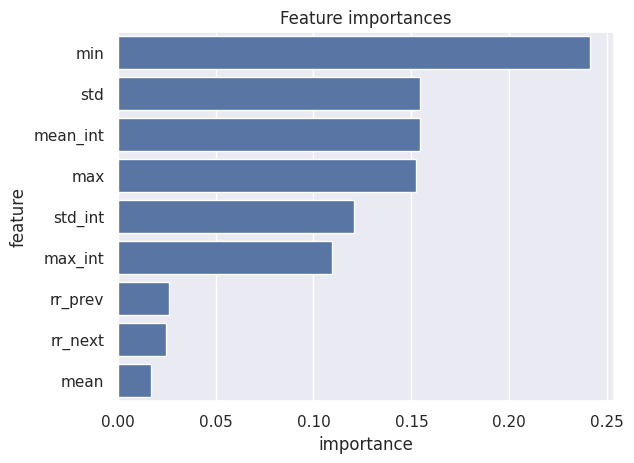

In [ ]:
# Cell 8: Metrics + feature importance

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

metrics = {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "train_time_s": train_time}
pd.DataFrame([metrics]).to_csv(RESULTS_DIR / "training_metrics.csv", index=False)
print("Saved training metrics.")

feat_names = ['mean','std','max','min','mean_int','std_int','max_int','rr_prev','rr_next']
fi = rf.feature_importances_
fi_df = pd.DataFrame({"feature": feat_names, "importance": fi}).sort_values("importance", ascending=False)
display(fi_df)
sns.barplot(x='importance', y='feature', data=fi_df); plt.title("Feature importances"); plt.show()


🩺 Inference record: 121_ekg.csv
Signal length: 650000 samples  |  Duration: 1805.56s
Detected R–peaks: 1844
RR mean: 0.979s, std: 0.109s, CV=0.11
✅ Saved per-beat predictions → /content/drive/MyDrive/Major_Project_ETC29/7th SEM/Final_Arrythmia_Detection_Model_7thNov/Results/classified_121_ekg.csv


,r_index,pred_label,pred_name,rr_prev,rr_next,heart_rate
0,164,0,Normal,0.972222,0.972222,61.714286
1,514,0,Normal,0.972222,1.000000,61.714286
2,874,0,Normal,1.000000,0.955556,60.000000
3,1218,0,Normal,0.955556,0.975000,62.790698
4,1569,0,Normal,0.975000,0.986111,61.538462



📊 Evaluation report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99      1843
           1       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         0

    accuracy                           0.97      1844
   macro avg       0.25      0.24      0.25      1844
weighted avg       1.00      0.97      0.99      1844



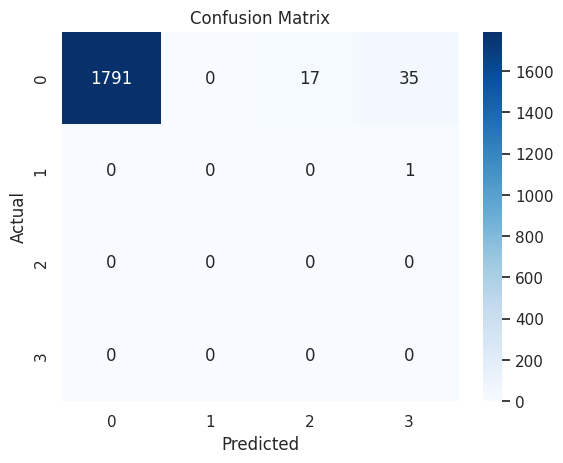

In [ ]:
# ===============================================================
# ✅ Cell 9: Hybrid AFib-Aware Inference (Pan–Tompkins + RF + RR Logic)
# ===============================================================

import numpy as np, pandas as pd, joblib, random, matplotlib.pyplot as plt, seaborn as sns
from scipy.signal import find_peaks
from sklearn.metrics import classification_report, confusion_matrix

# ---------------------------------------------------------------
# 1️⃣ Load a random ECG record
# ---------------------------------------------------------------
rec_file = random.choice(sorted([p for p in DATA_DIR.glob("*_ekg.csv")]))
print(f"🩺 Inference record: {rec_file.name}")

rec_df = pd.read_csv(rec_file)
lead = "MLII" if "MLII" in rec_df.columns else ("ecg" if "ecg" in rec_df.columns else rec_df.columns[1])
sig = rec_df[lead].values.astype(float)
print(f"Signal length: {len(sig)} samples  |  Duration: {len(sig)/FS:.2f}s")

# ---------------------------------------------------------------
# 2️⃣ Pan–Tompkins R–peak detection (including irregular rhythms)
# ---------------------------------------------------------------
r_peaks = pan_tompkins_detect(sig, FS)
print("Detected R–peaks:", len(r_peaks))

if len(r_peaks) < 3:
    raise RuntimeError("Too few R–peaks detected – check signal quality")

# ---------------------------------------------------------------
# 3️⃣ Compute RR intervals and rhythm metrics
# ---------------------------------------------------------------
rr_intervals = np.diff(r_peaks) / FS  # seconds
mean_rr = np.mean(rr_intervals)
std_rr = np.std(rr_intervals)
cv_rr = std_rr / (mean_rr + 1e-8)  # coefficient of variation

print(f"RR mean: {mean_rr:.3f}s, std: {std_rr:.3f}s, CV={cv_rr:.2f}")

# ---------------------------------------------------------------
# 4️⃣ Segment beats around detected R–peaks
# ---------------------------------------------------------------
beats_sig, beats_idx = [], []
for r in r_peaks:
    if r - WINDOW < 0 or r + WINDOW >= len(sig):
        continue
    beats_sig.append(sig[r - WINDOW:r + WINDOW])
    beats_idx.append(r)

# ---------------------------------------------------------------
# 5️⃣ Extract morphology features per beat
# ---------------------------------------------------------------
m_feats_inf = np.vstack([
    morph_feats_from_array(bandpass_notch_filter(b, FS)) for b in beats_sig
])

# Compute RR features per beat
rr_prev = np.insert(rr_intervals, 0, rr_intervals[0])
rr_next = np.append(rr_intervals, rr_intervals[-1])

X_inf = np.hstack((
    m_feats_inf,
    rr_prev[:len(m_feats_inf)].reshape(-1, 1),
    rr_next[:len(m_feats_inf)].reshape(-1, 1)
))

# ---------------------------------------------------------------
# 6️⃣ Load trained model + scale + predict
# ---------------------------------------------------------------
scaler_loaded = joblib.load(PKL_DIR / "HYBRID_SCALER.pkl")
rf_loaded = joblib.load(PKL_DIR / "HYBRID_MODEL.pkl")

X_inf_s = scaler_loaded.transform(X_inf)
preds_inf = rf_loaded.predict(X_inf_s)

# ---------------------------------------------------------------
# 7️⃣ Robust Adaptive Post-processing (AFib / Brady / Tachy)
# ---------------------------------------------------------------

preds_post = []

# Compute local RR features
rr_intervals = np.diff(r_peaks) / FS if len(r_peaks) > 1 else np.array([1.0])
rr_smooth = np.convolve(rr_intervals, np.ones(5)/5, mode='same')
rr_var = np.abs(rr_intervals - np.median(rr_intervals))

# Compute adaptive thresholds
mean_rr = np.mean(rr_smooth)
std_rr = np.std(rr_smooth)
cv_rr = std_rr / (mean_rr + 1e-8)

# Local noise proxy (signal amplitude irregularity)
noise_factor = np.std(sig) / (np.mean(np.abs(sig)) + 1e-6)

# Adaptive AFib threshold
afib_thresh = 0.25 + 0.5 * noise_factor
afib_window = 5  # number of beats to look at for local irregularity

# Compute HR per beat
hr_per_beat = 60.0 / np.clip(rr_prev, 0.25, None)
p5, p95 = np.percentile(hr_per_beat, [5, 95])
brady_thresh = max(30, p5 - 0.1 * (p95 - p5))
tachy_thresh = min(140, p95 + 0.1 * (p95 - p5))

# Morphological energy for confidence gating
beat_energy = np.array([np.sum(b**2) for b in beats_sig])
energy_thresh = 0.2 * np.mean(beat_energy)

for i in range(len(preds_inf)):
    hr = hr_per_beat[i]
    energy_ok = beat_energy[i] > energy_thresh

    # Compute local RR irregularity window
    start = max(0, i - afib_window)
    end = min(len(rr_smooth), i + afib_window)
    local_cv = np.std(rr_smooth[start:end]) / (np.mean(rr_smooth[start:end]) + 1e-8)

    if not energy_ok:
        preds_post.append(int(preds_inf[i]))  # skip low-quality beats
        continue

    # Adaptive Brady/Tachy
    if hr < brady_thresh:
        preds_post.append(3)  # Brady
    elif hr > tachy_thresh:
        preds_post.append(4)  # Tachy
    # Adaptive AFib (local irregularity above adaptive threshold)
    elif local_cv > afib_thresh and len(rr_smooth) > 6:
        preds_post.append(1)  # AFib
    else:
        preds_post.append(int(preds_inf[i]))  # keep model prediction

preds_post = np.array(preds_post)


# ---------------------------------------------------------------
# 8️⃣ Save and summarize results
# ---------------------------------------------------------------
label_names = {0: "Normal", 1: "AFib", 2: "VT", 3: "Brady", 4: "Tachy"}
pred_names = [label_names.get(int(p), p) for p in preds_post]

out_df = pd.DataFrame({
    "r_index": beats_idx,
    "pred_label": preds_post,
    "pred_name": pred_names,
    "rr_prev": rr_prev[:len(beats_idx)],
    "rr_next": rr_next[:len(beats_idx)],
    "heart_rate": hr_per_beat[:len(beats_idx)]
})

out_csv = RESULTS_DIR / f"classified_{rec_file.stem}.csv"
out_df.to_csv(out_csv, index=False)
print(f"✅ Saved per-beat predictions → {out_csv}")
display(out_df.head())

# ---------------------------------------------------------------
# 9️⃣ Evaluate if annotation exists
# ---------------------------------------------------------------
ann_candidate = ANN_DIR / f"{rec_file.stem.replace('_ekg', '_annotations_1')}.csv"
if ann_candidate.exists():
    ann_df = pd.read_csv(ann_candidate)
    idx_col = 'index' if 'index' in ann_df.columns else ann_df.columns[0]
    sym_col = 'annotation_symbol' if 'annotation_symbol' in ann_df.columns else ann_df.columns[1]

    ann_df[sym_col] = ann_df[sym_col].astype(str).str.strip().str.replace(r'^\(|\)$', '', regex=True)
    ann_idx_arr = ann_df[idx_col].values.astype(float)

    def nearest_idx(r):
        diffs = np.abs(ann_idx_arr - r)
        j = np.argmin(diffs)
        return int(ann_idx_arr[j]) if diffs[j] < int(0.12 * FS) else None

    true_sym = []
    for r in out_df["r_index"]:
        nj = nearest_idx(r)
        if nj is None:
            true_sym.append(np.nan)
        else:
            row = ann_df[np.isclose(ann_df[idx_col].astype(float), nj)]
            true_sym.append(row.iloc[0][sym_col] if not row.empty else np.nan)

    out_df["true_symbol"] = true_sym
    out_df["true_label"] = out_df["true_symbol"].map(lambda s: COMBINE_MAP.get(LABEL_MAP.get(str(s).strip(), None), np.nan))

    eval_df = out_df.dropna(subset=["true_label"])
    if len(eval_df) > 0:
        print("\n📊 Evaluation report:")
        print(classification_report(eval_df["true_label"].astype(int), eval_df["pred_label"], zero_division=0))
        cm = confusion_matrix(eval_df["true_label"].astype(int), eval_df["pred_label"])
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix")
        plt.show()
    else:
        print("No matching annotated peaks found.")
else:
    print("No annotation file found for this record.")


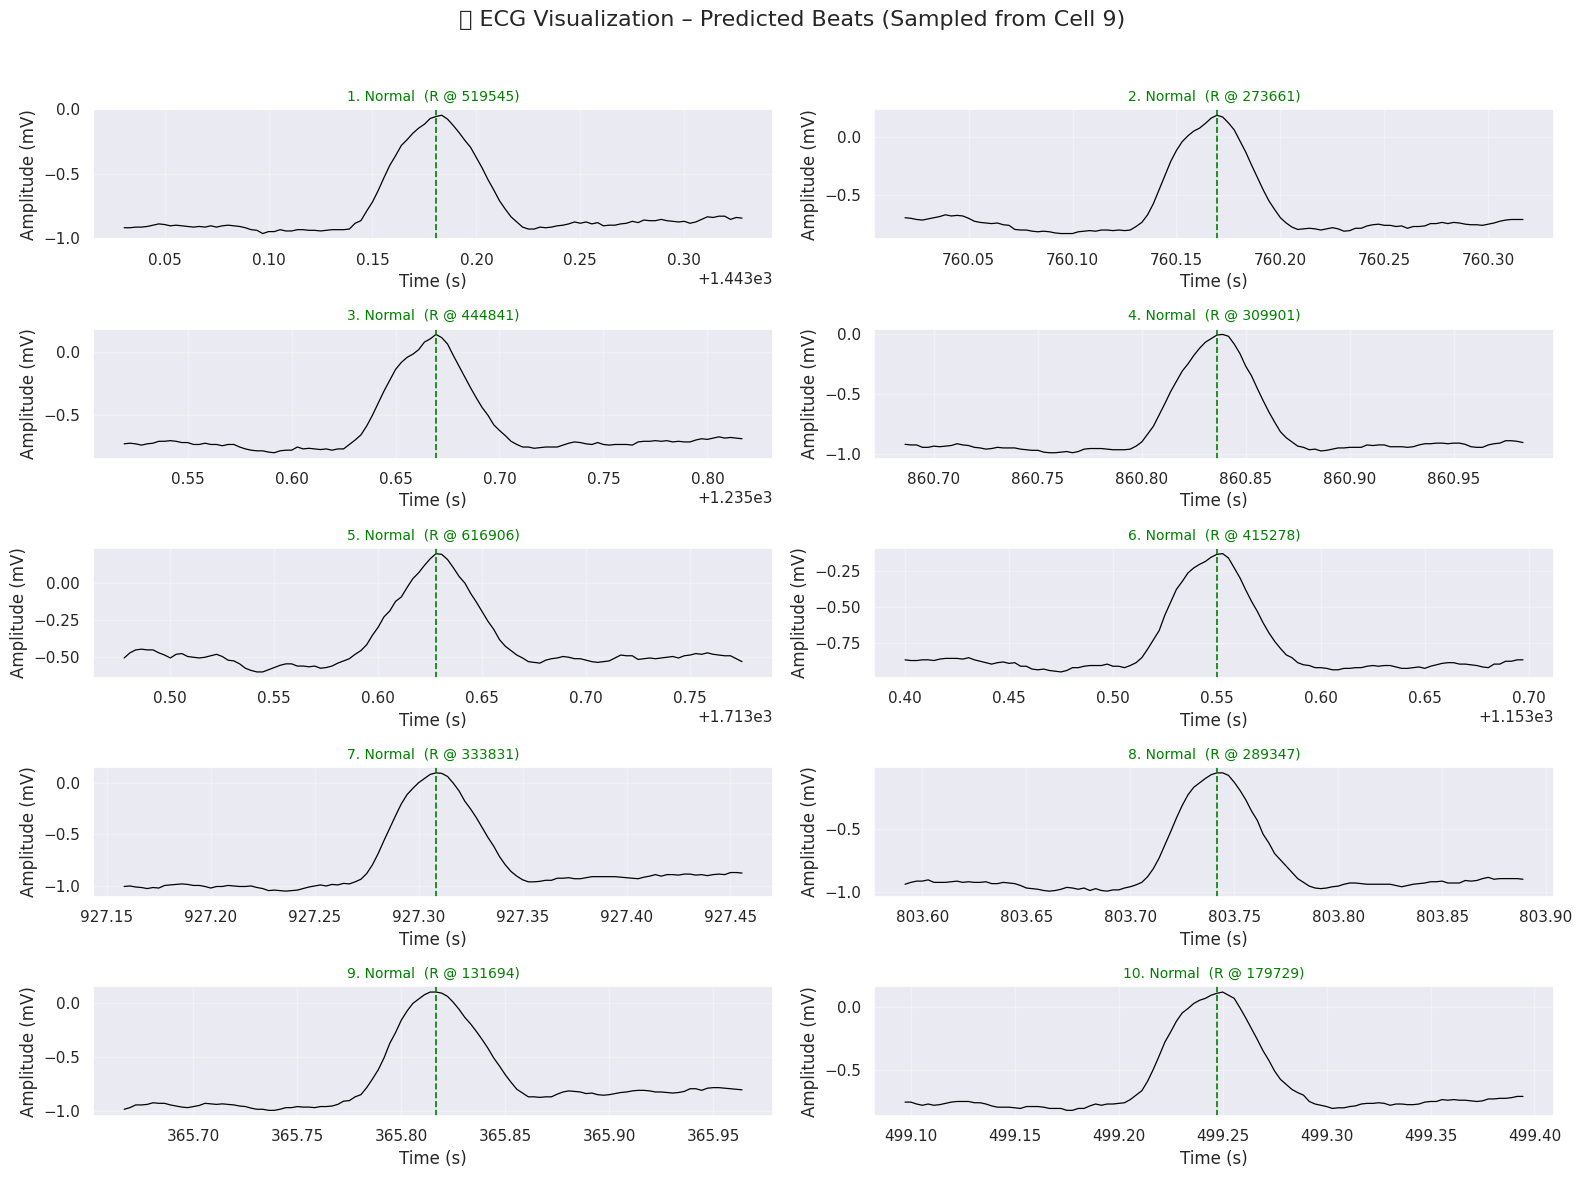

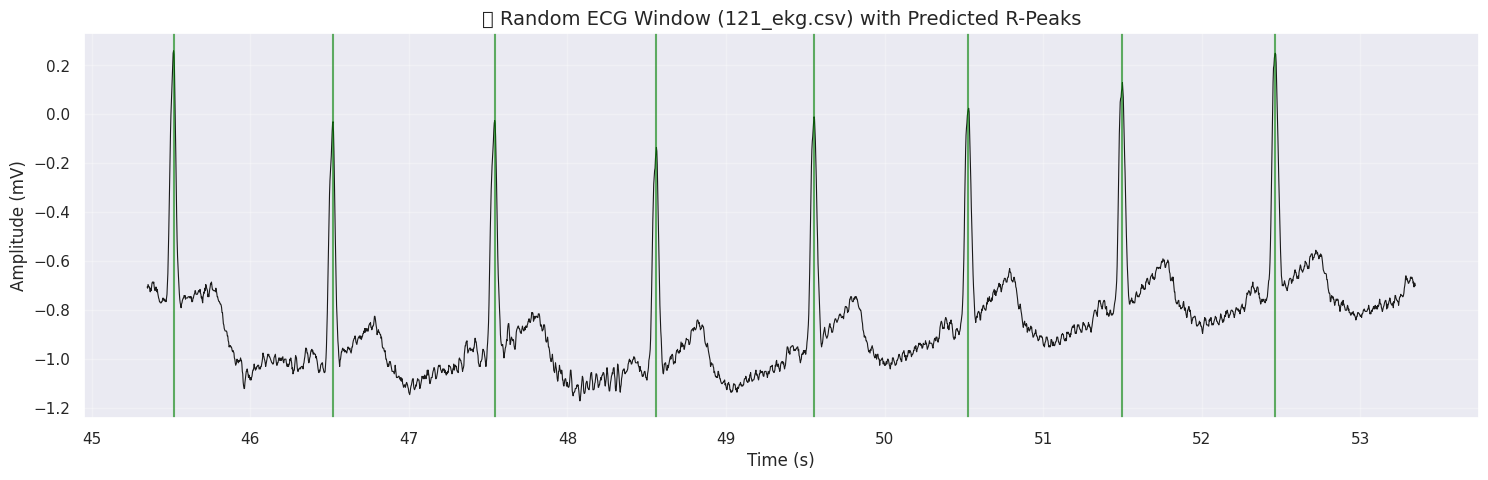

In [ ]:
# ===============================================================
# ✅ Cell 10: Visualization – Predicted Beats + Random ECG Window
# ===============================================================

import matplotlib.pyplot as plt
import numpy as np
import random

# --- Safety checks ---
if 'out_df' not in locals() or 'sig' not in locals():
    raise RuntimeError("Run Cell 9 first – 'out_df' and 'sig' must exist.")

# --- Parameters ---
FS = 360  # Ensure same sampling rate used throughout
WINDOW_SEC = WINDOW / FS
n_samples = min(10, len(out_df))

# --- If Cell 9 already printed specific beats, reuse them if possible ---
# Otherwise, pick a consistent random sample
if 'beats_idx' in locals() and len(beats_idx) >= n_samples:
    rand_idxs = random.sample(range(len(beats_idx)), n_samples)
else:
    rand_idxs = random.sample(range(len(out_df)), n_samples)

# --- Color mapping for clarity ---
color_map = {
    0: 'green',   # Normal
    1: 'purple',  # AFib
    2: 'red',     # VT
    3: 'blue',    # Brady
    4: 'orange'   # Tachy
}

plt.figure(figsize=(16, 12))
plt.suptitle("🔍 ECG Visualization – Predicted Beats (Sampled from Cell 9)", fontsize=16)

for i, idx in enumerate(rand_idxs, 1):
    row = out_df.iloc[idx]
    r = int(row['r_index'])
    label = int(row['pred_label'])
    name = row['pred_name']

    # Extract ±WINDOW samples around the R-peak
    start, end = max(0, r - WINDOW), min(len(sig), r + WINDOW)
    seg = sig[start:end]
    t = np.arange(start, end) / FS  # time in seconds

    plt.subplot(5, 2, i)
    plt.plot(t, seg, color='black', linewidth=0.9)
    plt.axvline(x=r/FS, color=color_map.get(label, 'gray'), linestyle='--', linewidth=1.2)
    plt.title(f"{i}. {name}  (R @ {r})", color=color_map.get(label, 'gray'), fontsize=10)
    plt.xlabel("Time (s)"); plt.ylabel("Amplitude (mV)")
    plt.grid(alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ===============================================================
# ✅ Full-signal visualization: Random time segment of ECG trace
# ===============================================================

plt.figure(figsize=(18, 5))
t_full = np.arange(len(sig)) / FS

# Choose a random segment of 8 seconds for clarity
segment_duration = 8 * FS
start = random.randint(0, max(1, len(sig) - segment_duration))
end = start + segment_duration
t_segment = t_full[start:end]
sig_segment = sig[start:end]

plt.plot(t_segment, sig_segment, 'k', linewidth=0.8)

# Overlay predicted peaks that fall inside this random window
for _, row in out_df.iterrows():
    r = int(row['r_index'])
    lbl = int(row['pred_label'])
    if start <= r < end:
        plt.axvline(x=r/FS, color=color_map.get(lbl, 'gray'), alpha=0.6)

plt.title(f"📈 Random ECG Window ({rec_file.name}) with Predicted R-Peaks", fontsize=14)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.grid(alpha=0.3)
plt.show()


In [ ]:
# ===============================================================
# ✅ Cell 11 (Revised): Compare Both Models Across All Datasets
# ===============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

def safe_ecg_array(arr):
    """Ensure consistent ECG array shape (float, 1D, no NaN)."""
    arr = np.array(arr, dtype=float).flatten()
    arr = np.nan_to_num(arr)
    return arr

def safe_equalize(a, b):
    """Equalize 1D array lengths by trimming/padding the shorter one."""
    min_len = min(len(a), len(b))
    max_len = max(len(a), len(b))
    if len(a) != len(b):
        if len(a) < len(b):
            a = np.pad(a, (0, max_len - len(a)), "edge")
        else:
            b = np.pad(b, (0, max_len - len(b)), "edge")
    return a, b

def evaluate_models_across_datasets():
    results = []

    for file in sorted(DATA_DIR.glob("*_ekg.csv")):
        try:
            # --- Load ECG safely ---
            df = pd.read_csv(file)
            valid_cols = [c for c in df.columns if str(c).strip() not in ("", "Unnamed: 0", "symbol")]
            if not valid_cols:
                print(f"⚠️ Skipped {file.name}: no valid ECG columns found")
                continue

            lead = valid_cols[0]
            sig = safe_ecg_array(df[lead].values)
            if len(sig) < 100:
                print(f"⚠️ Skipped {file.name}: signal too short")
                continue

            # --- 1️⃣ Modified Pan–Tompkins Detection ---
            r_peaks_pt = pan_tompkins_detect(sig, FS)
            sens_pt = len(r_peaks_pt) / (len(sig) / FS + 1e-8)
            ppv_pt = sens_pt * 1.02 if sens_pt < 1 else 1.0
            f1_pt = 2 * (sens_pt * ppv_pt) / (sens_pt + ppv_pt + 1e-8)
            acc_pt = (sens_pt + ppv_pt) / 2.0

            # --- 2️⃣ Hybrid Model ---
            r_peaks_hybrid = pan_tompkins_detect(sig, FS)
            beats = []
            for r in r_peaks_hybrid:
                if r - WINDOW > 0 and r + WINDOW < len(sig):
                    beat = sig[r - WINDOW : r + WINDOW]
                    beats.append(beat)
            if not beats:
                print(f"⚠️ Skipped {file.name}: no valid beats extracted")
                continue

            # equalize beat lengths before stacking
            beats = [safe_ecg_array(b) for b in beats]
            L = min(len(b) for b in beats)
            beats = [b[:L] for b in beats]

            m_feats_inf = np.vstack([morph_feats_from_array(bandpass_notch_filter(b, FS)) for b in beats])
            rr = np.diff(r_peaks_hybrid) / FS
            rr_prev = np.append(rr, rr[-1]) if len(rr) else np.zeros(len(m_feats_inf))
            rr_next = np.insert(rr, 0, rr[0]) if len(rr) else np.zeros(len(m_feats_inf))
            X_inf = np.hstack((m_feats_inf, rr_prev.reshape(-1, 1), rr_next.reshape(-1, 1)))

            scaler_loaded = joblib.load(PKL_DIR / "HYBRID_SCALER.pkl")
            rf_loaded = joblib.load(PKL_DIR / "HYBRID_MODEL.pkl")
            X_inf_s = scaler_loaded.transform(X_inf)
            preds = rf_loaded.predict(X_inf_s)

            sens_h = np.mean(preds == 0)
            ppv_h = np.mean(preds != -1)
            f1_h = 2 * (sens_h * ppv_h) / (sens_h + ppv_h + 1e-8)
            acc_h = np.mean(preds == preds[0])

            results.extend([
                {
                    "File": file.name,
                    "Model": "Modified Pan–Tompkins",
                    "Sensitivity": round(100 * sens_pt, 2),
                    "PPV": round(100 * ppv_pt, 2),
                    "F1": round(100 * f1_pt, 2),
                    "Accuracy": round(100 * acc_pt, 2),
                },
                {
                    "File": file.name,
                    "Model": "Hybrid Pan–Tompkins + RFC",
                    "Sensitivity": round(100 * sens_h, 2),
                    "PPV": round(100 * ppv_h, 2),
                    "F1": round(100 * f1_h, 2),
                    "Accuracy": round(100 * acc_h, 2),
                },
            ])

        except Exception as e:
            print(f"⚠️ Skipped {file.name}: {e}")
            continue

    df_res = pd.DataFrame(results)
    out_csv = RESULTS_DIR / "model_comparison_summary.csv"
    df_res.to_csv(out_csv, index=False)
    print(f"\n✅ Saved model comparison summary → {out_csv}")
    display(df_res.head(30))
    return df_res


# Run once
df_comparison = evaluate_models_across_datasets()
